Dharmraj sodha - 24SOECE13043

# Decision Tree

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [147]:
users = pd.read_csv('datasets/users.csv')
users

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0
...,...,...,...,...,...
94,15786993,Female,45,83000,0
95,15709441,Female,35,44000,0
96,15710257,Female,4,25000,0
97,15582492,Male,5,123000,1


In [148]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          99 non-null     int64
 1   Gender           99 non-null     str  
 2   Age              99 non-null     int64
 3   EstimatedSalary  99 non-null     int64
 4   Purchased        99 non-null     int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB


In [149]:
users['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [150]:
users['Purchased'].unique()

array([0, 1])

In [151]:
users['Age'].min(), users['Age'].max()

(np.int64(1), np.int64(64))

In [152]:
users['EstimatedSalary'].min(), users['EstimatedSalary'].max()

(np.int64(15000), np.int64(150000))

In [153]:
# x = users.columns.drop(['User ID', 'Purchased'])
x = users.columns.drop('Purchased')
y = users['Purchased']

In [154]:
x

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary'], dtype='str')

In [155]:
users_encoded = pd.get_dummies(users[x]).astype(int)

In [156]:
users_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [157]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# scaler = MinMaxScaler()
# users_scaled = scaler.fit_transform(users_encoded)
# users_scaled = pd.DataFrame(users_scaled, columns=users_encoded.columns)
# users_scaled
# x_train, x_test, y_train, y_test = train_test_split(users_scaled, y, test_size=0.2, random_state=42)

In [158]:
x_train, x_test, y_train, y_test = train_test_split(users_encoded, y, test_size=0.2, random_state=42)

In [159]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((79, 5), (20, 5), (79,), (20,))

In [160]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [161]:
model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=1)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [162]:
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

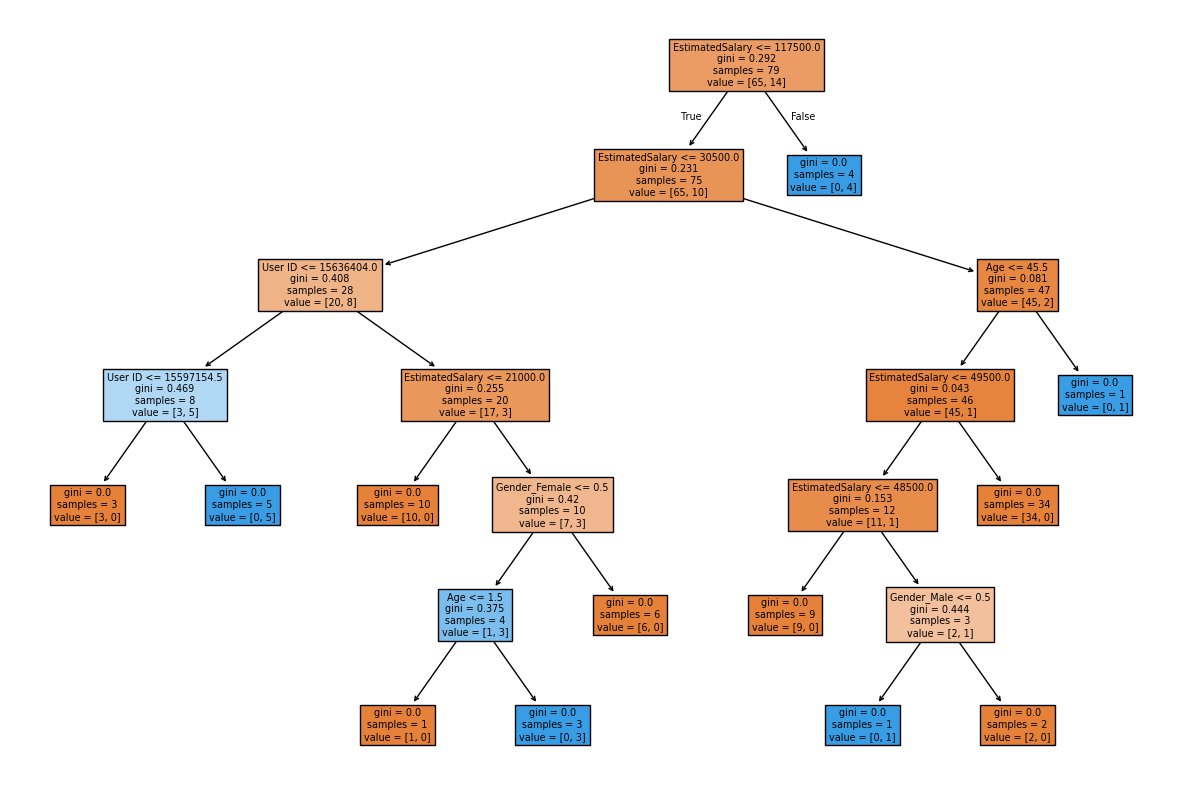

In [163]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=users_encoded.columns, filled=True)
plt.show()

In [164]:
train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)
print(f'Train Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

Train Accuracy: 1.00
Test Accuracy: 0.85


---
# Exercise 2 : Naive Bayes classification
---

### 1. Download and read dataset iris.csv

In [152]:
iris = pd.read_csv('./datasets/iris.csv')
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### 2. Import necessary files to implement Gaussian Naive Bayes classification

In [153]:
from sklearn.datasets import load_iris  
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

### 3. Perform Label encoding with required columns

In [154]:
from sklearn.preprocessing import LabelEncoder

LabelEncoder = LabelEncoder()

# Apply label encoding on 'species' column
iris['Species'] = LabelEncoder.fit_transform(iris['Species'])

iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### 4. Implement Gaussian Naive Bayes classification

In [155]:
X = iris[['Petal.Length','Petal.Width']]
y = iris['Species']

In [156]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2)

In [157]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [158]:
print("Model accuracy in train data: ",model.score(X_train,y_train)*100,"%")
print("Model accuracy in test data: ",model.score(X_test,y_test)*100,"%")

Model accuracy in train data:  95.0 %
Model accuracy in test data:  100.0 %


### 5. Print confusion matrix and classification report

In [159]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3 1 3]
 [3 5 7]
 [4 3 1]]


In [160]:
# Classification Report
cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.43      0.35         7
           1       0.56      0.33      0.42        15
           2       0.09      0.12      0.11         8

    accuracy                           0.30        30
   macro avg       0.32      0.30      0.29        30
weighted avg       0.37      0.30      0.32        30



# Ensembling models can be categorised into 
 
 Bagging model = the combined models work parallely on parts of the training data and their results are aggregated 

 Boostting mdoel - the combined models work sequentially on the entire data , subsequent models  rectify the errors of previous models (multiple weeker models , chainted to become a single storng model )

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [166]:
spam_data = pd.read_csv('datasets/spambase.csv')
spam_data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [167]:
spam_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [168]:
from sklearn.model_selection import train_test_split
features = spam_data.columns.drop('spam')
target = 'spam'
X = spam_data[features]
Y = spam_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=100)

In [169]:
X = spam_data.iloc[:, :-1]
Y = spam_data.iloc[:, -1]

## Method 1 : Train Random Forest (Bagging)

In [199]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,min_samples_split=20,min_impurity_decrease=0.01)
rf_model.fit(X_train, y_train)
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)
print(f'Train Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

Train Accuracy: 0.91
Test Accuracy: 0.92


## Method 2: boosting using Adaboost Algorithm

In [204]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=1000)
ada_model.fit(X_train, y_train)
train_accuracy = ada_model.score(X_train, y_train)
test_accuracy = ada_model.score(X_test, y_test)
print(f'Train Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

Train Accuracy: 0.96
Test Accuracy: 0.95


In [208]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = ada_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)

Accuracy: 0.95
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       546
           1       0.95      0.94      0.94       375

    accuracy                           0.95       921
   macro avg       0.95      0.95      0.95       921
weighted avg       0.95      0.95      0.95       921

